# Lab 4: Two-Body Collisions

**Name:** Alex Bebb  
**Course:** PHYS 311 — Classical Mechanics I  
**Date:** September 20, 2026  

## Purpose

In this lab, I will model collisions in one and two dimensions and
investigate how the coefficient of restitution affects the results.
I will check momentum and kinetic energy to see whether the collisions
behave as expected, then examine the motion of the center of mass.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Default appearance for the plots in this notebook.
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.grid"] = True

## Part A: One-Dimensional Collisions

### Calculating the velocities after a collision

I will define a function that calculates the final velocities of two
objects from their masses, initial velocities, and coefficient of
restitution. The model assumes that external impulses are negligible
during the collision, so total momentum is conserved.

The coefficient of restitution, $e$, describes the relative velocity
after the collision compared with before it:

$$
v_2-v_1=e(u_1-u_2).
$$

Here, $u_1$ and $u_2$ are the initial velocities, and $v_1$ and $v_2$
are the final velocities. An elastic collision has $e=1$ and conserves
kinetic energy. When $e=0$, the objects have the same final velocity.
Values between zero and one describe partially inelastic collisions.

The function will first calculate the center-of-mass velocity:

$$
v_{\mathrm{cm}}=\frac{m_1u_1+m_2u_2}{m_1+m_2}.
$$

Combining conservation of momentum with the restitution equation gives:

$$
v_1=v_{\mathrm{cm}}-\frac{em_2}{m_1+m_2}(u_1-u_2),
$$

$$
v_2=v_{\mathrm{cm}}+\frac{em_1}{m_1+m_2}(u_1-u_2).
$$

I will use kilograms for mass and meters per second for velocity.
Positive and negative velocities indicate opposite directions.

In [2]:
def collide_1d(m1, m2, u1, u2, e=1.0):
    """Return the final velocities for a one-dimensional collision."""

    # Find the velocity of the center of mass.
    v_cm = (m1 * u1 + m2 * u2) / (m1 + m2)

    # Calculate each object's velocity after the collision.
    v1 = v_cm - (e * m2 / (m1 + m2)) * (u1 - u2)
    v2 = v_cm + (e * m1 / (m1 + m2)) * (u1 - u2)

    return v1, v2

### Testing the collision function

I will test three mass combinations with elastic collisions ($e=1$).
In each case, the first object will move at $4.0\ \mathrm{m/s}$ toward
a stationary second object.

For equal masses, the objects should exchange velocities: the first
should stop, and the second should move at the first object's initial
velocity.

A light object hitting a much heavier object should bounce back with
nearly its original speed. The heavier object should move forward slowly.

A heavy object hitting a much lighter object should continue forward
with little change in velocity. The lighter object should move forward
at nearly twice the heavy object's initial velocity.

I will compare the calculated velocities with these predictions.

In [3]:
# Each tuple contains a case label and the two masses in kilograms.
test_cases = [
    ("Equal masses", 1.0, 1.0),
    ("Light into heavy", 0.1, 100.0),
    ("Heavy into light", 100.0, 0.1),
]

# Initial velocities in m/s.
u1 = 4.0
u2 = 0.0

print(f"{'Case':<20} {'v1 (m/s)':>12} {'v2 (m/s)':>12}")

# Calculate and display the final velocities for each mass combination.
for label, m1, m2 in test_cases:
    v1, v2 = collide_1d(m1=m1, m2=m2, u1=u1, u2=u2, e=1.0)
    print(f"{label:<20} {v1:>12.6f} {v2:>12.6f}")

Case                     v1 (m/s)     v2 (m/s)
Equal masses             0.000000     4.000000
Light into heavy        -3.992008     0.007992
Heavy into light         3.992008     7.992008


### Checking momentum and kinetic energy

I will use masses of $m_1=2.0\ \mathrm{kg}$ and $m_2=3.0\ \mathrm{kg}$,
with initial velocities of $u_1=4.0\ \mathrm{m/s}$ and
$u_2=0.0\ \mathrm{m/s}$. I will compare collisions with restitution
values of $1.0$, $0.5$, and $0.0$.

Total momentum is calculated using:

$$
p=m_1v_1+m_2v_2.
$$

Total kinetic energy is calculated using:

$$
K=\frac{1}{2}m_1v_1^2+\frac{1}{2}m_2v_2^2.
$$

For the initial values, the total momentum is
$8.0\ \mathrm{kg\,m/s}$ and the kinetic energy is $16.0\ \mathrm{J}$.

Momentum should remain the same in all three collisions because
the model assumes no external impulse. Kinetic energy should remain
the same for the elastic collision and decrease when $e<1$.
I will calculate the kinetic energy loss as $K_i-K_f$.

In [4]:
# Masses in kg and initial velocities in m/s.
m1 = 2.0
m2 = 3.0
u1 = 4.0
u2 = 0.0

# Calculate the totals before the collision.
p_initial = m1 * u1 + m2 * u2
K_initial = 0.5 * m1 * u1**2 + 0.5 * m2 * u2**2

print(f"Initial momentum: {p_initial:.4f} kg m/s")
print(f"Initial kinetic energy: {K_initial:.4f} J")
print()

# Use fixed column widths to align the plain-text output.
print(
    f"{'e':>5} {'v1 (m/s)':>12} {'v2 (m/s)':>12} "
    f"{'p (kg m/s)':>14} {'K (J)':>12} {'K loss (J)':>12}"
)

for e in [1.0, 0.5, 0.0]:
    v1, v2 = collide_1d(m1=m1, m2=m2, u1=u1, u2=u2, e=e)

    p_final = m1 * v1 + m2 * v2
    K_final = 0.5 * m1 * v1**2 + 0.5 * m2 * v2**2
    K_loss = K_initial - K_final

    # Round only the displayed loss to avoid printing negative zero.
    loss_display = round(K_loss, 4)
    if loss_display == 0:
        loss_display = 0.0

    print(
        f"{e:>5.1f} {v1:>12.4f} {v2:>12.4f} "
        f"{p_final:>14.4f} {K_final:>12.4f} {loss_display:>12.4f}"
    )

Initial momentum: 8.0000 kg m/s
Initial kinetic energy: 16.0000 J

    e     v1 (m/s)     v2 (m/s)     p (kg m/s)        K (J)   K loss (J)
  1.0      -0.8000       3.2000         8.0000      16.0000       0.0000
  0.5       0.4000       2.4000         8.0000       8.8000       7.2000
  0.0       1.6000       1.6000         8.0000       6.4000       9.6000


### Part A results and interpretation

The initial momentum was $8.0\ \mathrm{kg\,m/s}$, and the initial
kinetic energy was $16.0\ \mathrm{J}$.

| e | v1 (m/s) | v2 (m/s) | Final p (kg m/s) | Final K (J) | K loss (J) |
|---|---|---|---|---|---|
| 1.0 | -0.8000 | 3.2000 | 8.0000 | 16.0000 | 0.0000 |
| 0.5 | 0.4000 | 2.4000 | 8.0000 | 8.8000 | 7.2000 |
| 0.0 | 1.6000 | 1.6000 | 8.0000 | 6.4000 | 9.6000 |

The three elastic test cases behaved as predicted. Equal masses
exchanged velocities, the light object bounced back from the heavy
object, and the heavy object transferred motion to the light object
while barely slowing down.

Momentum stayed the same for all three restitution values. Kinetic
energy was conserved when $e=1$ and decreased for the other two cases.
When $e=0$, both objects had the same final velocity, so there was no
relative motion between them after the collision.

The lost kinetic energy would be transferred into other forms, such
as deformation, thermal energy, and sound. The model does not track
those forms of energy directly; their effect is represented by the
coefficient of restitution.

## Part B: Two-Dimensional Collisions

### Calculating velocities after a collision

I will model the objects as smooth disks without friction or rotation.
Each disk will have a mass, position, velocity, and radius.

During a collision, the impulse acts along the line connecting the
centers of the disks. I will call this the normal direction. The
perpendicular direction is the tangential direction.

The function will separate each velocity into normal and tangential
components. It will use the one-dimensional collision function to
calculate the new normal components, while keeping the tangential
components unchanged.

The unit vector from the first disk's center to the second is:

$$
\hat{\mathbf{n}}=
\frac{\mathbf{r}_2-\mathbf{r}_1}
{|\mathbf{r}_2-\mathbf{r}_1|}.
$$

Taking the dot product of each velocity with this vector gives its
normal component:

$$
u_{1n}=\mathbf{v}_1\cdot\hat{\mathbf{n}},
\qquad
u_{2n}=\mathbf{v}_2\cdot\hat{\mathbf{n}}.
$$

After calculating the final normal components, the function will
update each velocity by adding only the change in the normal direction:

$$
\mathbf{v}_{1,\mathrm{new}}
=\mathbf{v}_1+(v_{1n}-u_{1n})\hat{\mathbf{n}},
$$

$$
\mathbf{v}_{2,\mathrm{new}}
=\mathbf{v}_2+(v_{2n}-u_{2n})\hat{\mathbf{n}}.
$$

A separate step will check whether the disks are touching and moving
toward each other before calling this function.

In [5]:
def collide_2d(body1, body2, e=1.0):
    """Update two disks' velocities using a frictionless collision rule."""

    # Find the direction from the first disk to the second.
    separation = body2["r"] - body1["r"]
    distance = np.linalg.norm(separation)

    # Coincident centers do not define a collision direction.
    if distance == 0:
        raise ValueError("The disks have the same center; collision direction is undefined.")

    normal = separation / distance

    # Project the velocities onto the normal direction.
    u1_normal = np.dot(body1["v"], normal)
    u2_normal = np.dot(body2["v"], normal)

    # Apply the one-dimensional collision rule to these components.
    v1_normal, v2_normal = collide_1d(
        m1=body1["m"],
        m2=body2["m"],
        u1=u1_normal,
        u2=u2_normal,
        e=e,
    )

    # Change only the normal components of the velocities.
    body1["v"] = body1["v"] + (v1_normal - u1_normal) * normal
    body2["v"] = body2["v"] + (v2_normal - u2_normal) * normal

### Reflecting the disks off the walls

I will place the disks inside a rectangular box extending from
$x=0$ to $x=L_x$ and from $y=0$ to $y=L_y$.

The wall checks will account for each disk's radius. For example, a
disk touches the left wall when its center is one radius away from
$x=0$.

When a disk crosses a wall boundary during a time step, the function
will move it back inside the box and reverse the velocity component
perpendicular to that wall. The parallel component will stay unchanged.

These wall collisions will be perfectly elastic, so the disk's speed
and kinetic energy should remain unchanged. However, the total
momentum of the disks can change because the walls exert external
impulses on them. Momentum should be conserved during collisions
between the disks, provided no wall collision occurs at the same time.

In [6]:
def reflect_walls(body, Lx, Ly):
    """Keep a disk inside the box and reflect its velocity at the walls."""

    radius = body["radius"]

    # Check the left and right walls.
    if body["r"][0] < radius:
        body["r"][0] = radius
        body["v"][0] = abs(body["v"][0])

    elif body["r"][0] > Lx - radius:
        body["r"][0] = Lx - radius
        body["v"][0] = -abs(body["v"][0])

    # Check the bottom and top walls.
    if body["r"][1] < radius:
        body["r"][1] = radius
        body["v"][1] = abs(body["v"][1])

    elif body["r"][1] > Ly - radius:
        body["r"][1] = Ly - radius
        body["v"][1] = -abs(body["v"][1])

### Running the simulation and storing the results

I will define a function that advances the disks through a chosen
number of time steps. Between collisions, no forces act on the disks,
so their velocities remain constant and their positions change according to:

$$
\mathbf{r}_{\mathrm{new}}=\mathbf{r}_{\mathrm{old}}+\mathbf{v}\Delta t.
$$

This is the zero-acceleration case of the Euler-Cromer update.

At each step, the function will move the disks and check for wall
collisions. It will then check each pair of disks for contact.
Two disks are touching or overlapping when the distance between
their centers is no greater than the sum of their radii.

The function will apply the collision rule only if the disks are also
moving toward each other. This condition is:

$$
(\mathbf{v}_2-\mathbf{v}_1)\cdot
(\mathbf{r}_2-\mathbf{r}_1)<0.
$$

This check prevents the function from repeatedly applying a collision
while overlapping disks are already moving apart.

The function will store time, positions, velocities, total momentum,
total kinetic energy, and center-of-mass position. These records will
allow me to plot the motion and check the physics.

Collisions are detected at discrete time steps, so the time step
must be small enough to prevent disks from passing through each
other between checks.

In [7]:
def simulate_disks(
    initial_bodies, dt=0.005, n_steps=1000,
    Lx=10.0, Ly=6.0, e=1.0, walls=True
):
    """Simulate moving disks and return their motion and physical totals."""

    # Copy the disks so a run does not change the original conditions.
    bodies = []
    for body in initial_bodies:
        bodies.append({
            "m": body["m"],
            "r": np.array(body["r"], dtype=float, copy=True),
            "v": np.array(body["v"], dtype=float, copy=True),
            "radius": body["radius"],
        })

    n_bodies = len(bodies)
    masses = np.array([body["m"] for body in bodies])
    total_mass = np.sum(masses)

    # Reserve storage, including the initial state at time zero.
    time = np.arange(n_steps + 1) * dt
    positions = np.zeros((n_steps + 1, n_bodies, 2))
    velocities = np.zeros((n_steps + 1, n_bodies, 2))
    momentum = np.zeros((n_steps + 1, 2))
    kinetic_energy = np.zeros(n_steps + 1)
    center_of_mass = np.zeros((n_steps + 1, 2))

    for step in range(n_steps + 1):

        # Store the current state and calculate the physical totals.
        for i, body in enumerate(bodies):
            positions[step, i] = body["r"]
            velocities[step, i] = body["v"]

            momentum[step] += body["m"] * body["v"]
            kinetic_energy[step] += (
                0.5 * body["m"] * np.dot(body["v"], body["v"])
            )
            center_of_mass[step] += body["m"] * body["r"]

        center_of_mass[step] /= total_mass

        # Stop after storing the final state.
        if step == n_steps:
            break

        # Advance the positions and handle wall reflections.
        for body in bodies:
            body["r"] = body["r"] + body["v"] * dt

            if walls:
                reflect_walls(body, Lx, Ly)

        # Check each distinct pair of disks once.
        for i in range(n_bodies):
            for j in range(i + 1, n_bodies):
                separation = bodies[j]["r"] - bodies[i]["r"]
                relative_velocity = bodies[j]["v"] - bodies[i]["v"]

                distance = np.linalg.norm(separation)
                contact_distance = bodies[i]["radius"] + bodies[j]["radius"]

                touching = distance <= contact_distance
                approaching = np.dot(relative_velocity, separation) < 0

                if touching and approaching:
                    collide_2d(bodies[i], bodies[j], e=e)

    return {
        "time": time,
        "positions": positions,
        "velocities": velocities,
        "momentum": momentum,
        "kinetic_energy": kinetic_energy,
        "center_of_mass": center_of_mass,
    }

### Setting up and running an elastic collision

I will use two disks with different masses and radii in a box
measuring 10 meters by 6 meters.

The first disk will have a mass of 2 kilograms and a radius of
0.30 meters. It will start at (2, 3) meters and move right at
2.0 meters per second.

The second disk will have a mass of 3 kilograms and a radius of
0.45 meters. It will start at (7, 3) meters and move left at
0.5 meters per second.

These initial conditions produce a head-on collision. Although the
simulation supports motion in two dimensions, this first test should
have no vertical motion and should agree with the one-dimensional
collision rule.

I will run the simulation for 3 seconds with a time step of
0.001 seconds and a coefficient of restitution of 1.0.
Neither disk should reach a wall during this run, so both total
momentum and total kinetic energy should remain constant.

In [8]:
# Box dimensions in meters.
Lx = 10.0
Ly = 6.0

# Time step in seconds and number of simulation steps.
dt = 0.001
n_steps = 3000

# Define the disks using SI units.
initial_bodies = [
    {
        "m": 2.0,
        "r": np.array([2.0, 3.0]),
        "v": np.array([2.0, 0.0]),
        "radius": 0.30,
    },
    {
        "m": 3.0,
        "r": np.array([7.0, 3.0]),
        "v": np.array([-0.5, 0.0]),
        "radius": 0.45,
    },
]

# Run the elastic collision simulation and save its results.
elastic_results = simulate_disks(
    initial_bodies=initial_bodies,
    dt=dt,
    n_steps=n_steps,
    Lx=Lx,
    Ly=Ly,
    e=1.0,
    walls=True,
)

# Display the duration and initial and final physical quantities.
print(f"Simulation duration: {elastic_results['time'][-1]:.3f} s")
print(f"Stored time points: {len(elastic_results['time'])}")

print("\nInitial momentum (kg m/s):",
      elastic_results["momentum"][0])
print("Final momentum (kg m/s):",
      elastic_results["momentum"][-1])

print(f"\nInitial kinetic energy: "
      f"{elastic_results['kinetic_energy'][0]:.6f} J")
print(f"Final kinetic energy: "
      f"{elastic_results['kinetic_energy'][-1]:.6f} J")

print("\nFinal velocity of disk 1 (m/s):",
      elastic_results["velocities"][-1, 0])
print("Final velocity of disk 2 (m/s):",
      elastic_results["velocities"][-1, 1])

Simulation duration: 3.000 s
Stored time points: 3001

Initial momentum (kg m/s): [2.5 0. ]
Final momentum (kg m/s): [2.5 0. ]

Initial kinetic energy: 4.375000 J
Final kinetic energy: 4.375000 J

Final velocity of disk 1 (m/s): [-1.  0.]
Final velocity of disk 2 (m/s): [1.5 0. ]


### Plotting the disk trajectories

I will plot the paths of both disk centers in the horizontal-vertical
plane. Since both disks start at the same height with no vertical
velocity, their paths should remain on the line $y=3\ \mathrm{m}$.

I will also plot each disk's horizontal position against time.
The slope of this graph represents horizontal velocity, so a change
in slope will show when the collision occurs. Both disks should
reverse direction after the collision.

The centers should remain separated by approximately the sum of
the radii at contact, rather than occupying the same position.

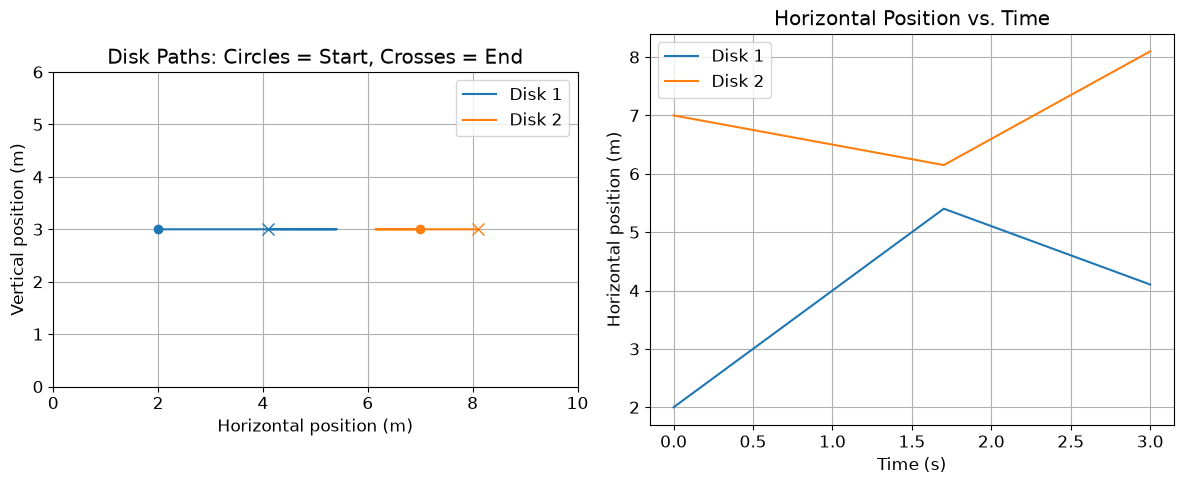

In [9]:
# Retrieve the stored times and positions.
time = elastic_results["time"]
positions = elastic_results["positions"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["tab:blue", "tab:orange"]

for i in range(len(initial_bodies)):
    # Select this disk's x and y positions at every stored time.
    x = positions[:, i, 0]
    y = positions[:, i, 1]

    # Plot the path of the disk's center.
    axes[0].plot(x, y, color=colors[i], label=f"Disk {i + 1}")
    axes[0].plot(x[0], y[0], "o", color=colors[i])
    axes[0].plot(x[-1], y[-1], "x", color=colors[i], markersize=9)

    # Plot horizontal position against time.
    axes[1].plot(time, x, color=colors[i], label=f"Disk {i + 1}")

axes[0].set(
    xlabel="Horizontal position (m)",
    ylabel="Vertical position (m)",
    title="Disk Paths: Circles = Start, Crosses = End",
    xlim=(0, Lx),
    ylim=(0, Ly),
)
axes[0].set_aspect("equal", adjustable="box")
axes[0].legend()

axes[1].set(
    xlabel="Time (s)",
    ylabel="Horizontal position (m)",
    title="Horizontal Position vs. Time",
)
axes[1].legend()

plt.tight_layout()
plt.show()

### Checking conservation throughout the simulation

I will plot both components of total momentum and the total kinetic
energy against time. Neither disk reaches a wall during this run,
so no external impulse should change the total momentum.

Because the collision is elastic, the total kinetic energy should
also remain constant. The expected values are:

$$
p_x=2.5\ \mathrm{kg\,m/s},
\qquad
p_y=0\ \mathrm{kg\,m/s},
\qquad
K=4.375\ \mathrm{J}.
$$

I will calculate the maximum deviation from each initial value over
the entire simulation. This checks for changes at intermediate times,
rather than only comparing the beginning and end.

These checks test conservation, but they do not establish that the
collision timing is exact. Collision detection still depends on the
time step.

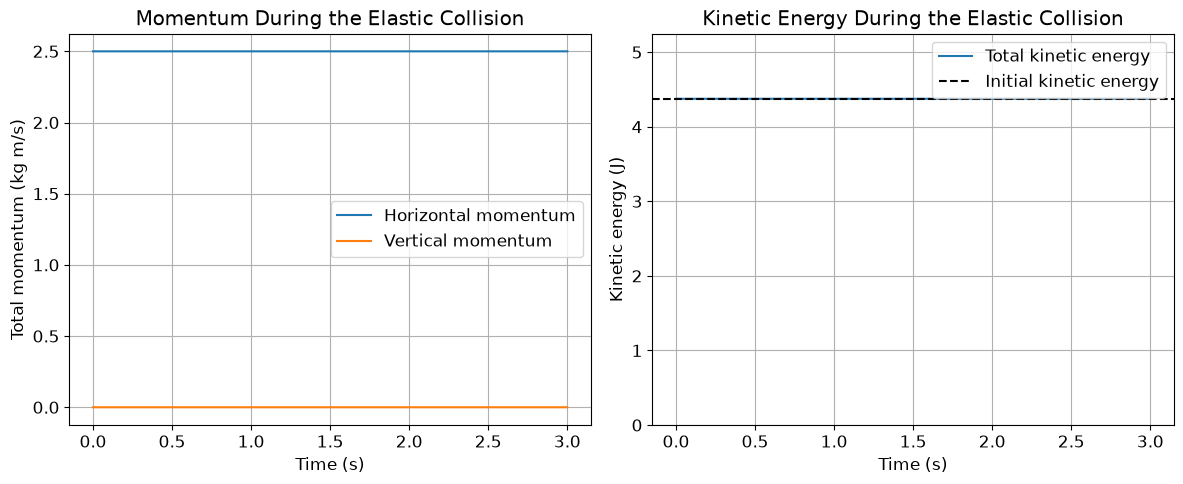

Maximum horizontal momentum change: 0.000e+00 kg m/s
Maximum vertical momentum change: 0.000e+00 kg m/s
Maximum kinetic energy change: 0.000e+00 J


In [10]:
# Retrieve the stored momentum and kinetic energy.
momentum = elastic_results["momentum"]
kinetic_energy = elastic_results["kinetic_energy"]
time = elastic_results["time"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot both components of total momentum.
axes[0].plot(time, momentum[:, 0], label="Horizontal momentum")
axes[0].plot(time, momentum[:, 1], label="Vertical momentum")
axes[0].set(
    xlabel="Time (s)",
    ylabel="Total momentum (kg m/s)",
    title="Momentum During the Elastic Collision",
)
axes[0].legend()

# Compare kinetic energy with its initial value.
axes[1].plot(time, kinetic_energy, label="Total kinetic energy")
axes[1].axhline(
    kinetic_energy[0],
    color="black",
    linestyle="--",
    label="Initial kinetic energy",
)
axes[1].set(
    xlabel="Time (s)",
    ylabel="Kinetic energy (J)",
    title="Kinetic Energy During the Elastic Collision",
)

# Use a scale that makes the constant energy easy to interpret.
axes[1].set_ylim(0, 1.2 * kinetic_energy[0])
axes[1].legend()

plt.tight_layout()
plt.show()

# Find the largest absolute deviation from each initial value.
max_px_change = np.max(np.abs(momentum[:, 0] - momentum[0, 0]))
max_py_change = np.max(np.abs(momentum[:, 1] - momentum[0, 1]))
max_energy_change = np.max(
    np.abs(kinetic_energy - kinetic_energy[0])
)

print(f"Maximum horizontal momentum change: {max_px_change:.3e} kg m/s")
print(f"Maximum vertical momentum change: {max_py_change:.3e} kg m/s")
print(f"Maximum kinetic energy change: {max_energy_change:.3e} J")

### Part B interpretation

The disks stayed at the same vertical position, as expected for
this head-on collision. The position-versus-time graph showed both
disks reversing direction at approximately 1.7 seconds. Their centers
remained separated by approximately the sum of their radii at contact.

The first disk's final horizontal velocity was -1.0 m/s, and the
second disk's was 1.5 m/s. These agree with the one-dimensional
elastic collision rule for the same masses and initial velocities.

Total horizontal momentum stayed at 2.5 kg m/s, vertical momentum
stayed at zero, and total kinetic energy stayed at 4.375 J, within
numerical precision. This supports the collision rule for this test.

Neither disk reached a wall, so the wall-reflection function was
not tested by this run. The head-on setup also did not test an
oblique collision with nonzero tangential velocity. Those would
provide additional checks of the two-dimensional model.

The conservation results do not mean that every part of the
simulation is exact. The disks move in finite time steps, so the
detected collision time and amount of overlap can depend on the
chosen time step.

## Part C: Inelastic Collisions

### Comparing different coefficients of restitution

I will repeat the simulation with restitution values of
$e=1.0,\ 0.9,\ 0.7,$ and $0.5$, keeping the masses, initial positions,
and initial velocities the same.

The elastic case should conserve kinetic energy. For the inelastic
cases, kinetic energy should decrease during the collision and
remain constant between collisions. A smaller restitution value
should produce a larger energy loss.

The walls remain perfectly elastic in this model. The restitution
value controls collisions between disks only.

Using the same initial conditions for every run will let me compare
the effect of restitution without changing other variables.

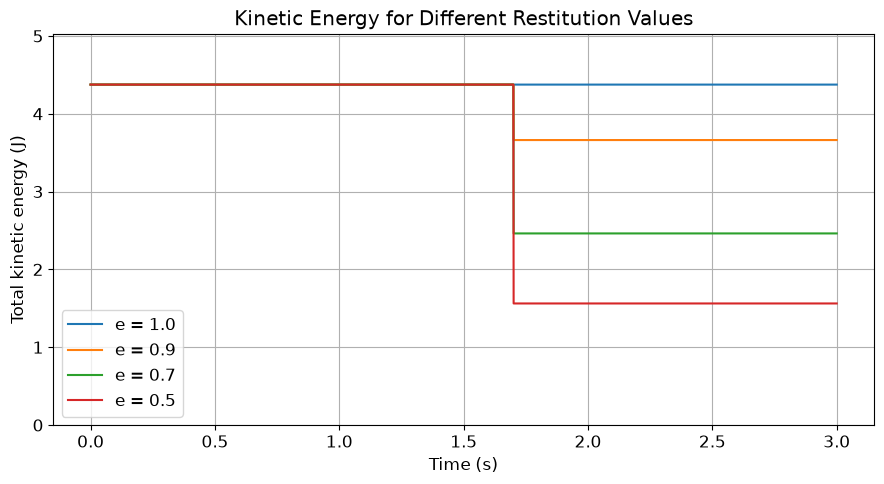

    e    Initial K (J)      Final K (J)       Loss (J)
  1.0         4.375000         4.375000       0.000000
  0.9         4.375000         3.662500       0.712500
  0.7         4.375000         2.462500       1.912500
  0.5         4.375000         1.562500       2.812500


In [11]:
# Restitution values for the disk-disk collision.
e_values = [1.0, 0.9, 0.7, 0.5]

# Store each run under its restitution value.
restitution_results = {}

for e in e_values:
    results = simulate_disks(
        initial_bodies=initial_bodies,
        dt=dt,
        n_steps=n_steps,
        Lx=Lx,
        Ly=Ly,
        e=e,
        walls=True,
    )

    restitution_results[e] = results

# Compare the kinetic energy histories.
plt.figure(figsize=(9, 5))

for e in e_values:
    results = restitution_results[e]

    plt.plot(
        results["time"],
        results["kinetic_energy"],
        label=f"e = {e:.1f}",
    )

plt.xlabel("Time (s)")
plt.ylabel("Total kinetic energy (J)")
plt.title("Kinetic Energy for Different Restitution Values")
plt.ylim(0, 1.15 * restitution_results[1.0]["kinetic_energy"][0])
plt.legend()
plt.tight_layout()
plt.show()

# Display the initial energy, final energy, and energy lost.
print(f"{'e':>5} {'Initial K (J)':>16} {'Final K (J)':>16} {'Loss (J)':>14}")

for e in e_values:
    energy = restitution_results[e]["kinetic_energy"]

    initial_K = energy[0]
    final_K = energy[-1]
    energy_loss = initial_K - final_K

    # Clean up negative zero in the displayed result.
    loss_display = round(energy_loss, 6)
    if loss_display == 0:
        loss_display = 0.0

    print(
        f"{e:>5.1f} {initial_K:>16.6f} "
        f"{final_K:>16.6f} {loss_display:>14.6f}"
    )

### Comparing the energy loss with theory

For a head-on collision, the predicted kinetic energy loss is:

$$
\Delta K=\frac{1}{2}\mu(1-e^2)(u_1-u_2)^2,
$$

where the reduced mass is:

$$
\mu=\frac{m_1m_2}{m_1+m_2}.
$$

For these disks, the reduced mass is 1.2 kg and their initial relative
speed is 2.5 m/s. Therefore:

$$
\Delta K=3.75(1-e^2)\ \mathrm{J}.
$$

I will compare the simulated fraction of kinetic energy lost with
the theoretical fraction:

$$
f_{\mathrm{loss}}=\frac{K_i-K_f}{K_i}.
$$

Each run contains one disk-disk collision and no wall collisions,
so the final energy is also the energy after the first collision.

The fraction of total kinetic energy lost is not simply $1-e^2$.
That factor applies to the kinetic energy associated with relative
motion in this head-on collision. The kinetic energy of the
center-of-mass motion remains unchanged.

    e    Numerical loss (%)     Theory loss (%)
  1.0              0.000000            0.000000
  0.9             16.285714           16.285714
  0.7             43.714286           43.714286
  0.5             64.285714           64.285714


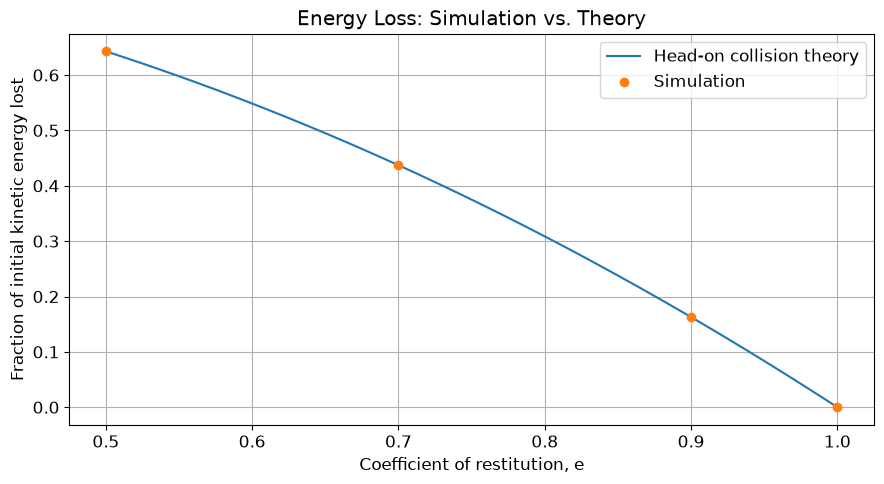


Maximum difference in loss fraction: 1.388e-16


In [12]:
# Retrieve the masses and initial horizontal velocities.
m1 = initial_bodies[0]["m"]
m2 = initial_bodies[1]["m"]
u1 = initial_bodies[0]["v"][0]
u2 = initial_bodies[1]["v"][0]

reduced_mass = m1 * m2 / (m1 + m2)
relative_speed = u1 - u2

numerical_fractions = []
theoretical_fractions = []

print(
    f"{'e':>5} {'Numerical loss (%)':>21} "
    f"{'Theory loss (%)':>19}"
)

for e in e_values:
    energy = restitution_results[e]["kinetic_energy"]
    initial_K = energy[0]
    final_K = energy[-1]

    # Calculate the simulated and predicted energy losses.
    numerical_loss = initial_K - final_K
    theoretical_loss = (
        0.5 * reduced_mass * (1 - e**2) * relative_speed**2
    )

    numerical_fraction = numerical_loss / initial_K
    theoretical_fraction = theoretical_loss / initial_K

    numerical_fractions.append(numerical_fraction)
    theoretical_fractions.append(theoretical_fraction)

    # Round the printed percentage to avoid displaying negative zero.
    numerical_percent = round(100 * numerical_fraction, 6)
    if numerical_percent == 0:
        numerical_percent = 0.0

    print(
        f"{e:>5.1f} {numerical_percent:>21.6f} "
        f"{100 * theoretical_fraction:>19.6f}"
    )

# Plot the theoretical curve over the tested restitution range.
e_curve = np.linspace(min(e_values), max(e_values), 200)
initial_K = restitution_results[1.0]["kinetic_energy"][0]

theory_curve = (
    0.5 * reduced_mass * (1 - e_curve**2) * relative_speed**2
    / initial_K
)

plt.figure(figsize=(9, 5))
plt.plot(e_curve, theory_curve, label="Head-on collision theory")
plt.scatter(
    e_values,
    numerical_fractions,
    color="tab:orange",
    zorder=3,
    label="Simulation",
)
plt.xlabel("Coefficient of restitution, e")
plt.ylabel("Fraction of initial kinetic energy lost")
plt.title("Energy Loss: Simulation vs. Theory")
plt.legend()
plt.tight_layout()
plt.show()

# Quantify agreement at the four tested restitution values.
max_fraction_error = np.max(
    np.abs(
        np.array(numerical_fractions)
        - np.array(theoretical_fractions)
    )
)

print(f"\nMaximum difference in loss fraction: {max_fraction_error:.3e}")

### Checking the center-of-mass motion

I will turn off the walls and repeat the simulations to check whether
the center of mass moves at a constant velocity.

The center-of-mass position is:

$$
\mathbf{R}_{\mathrm{cm}}
=\frac{m_1\mathbf{r}_1+m_2\mathbf{r}_2}{m_1+m_2}.
$$

Without external forces or wall impulses, the predicted motion is:

$$
\mathbf{R}_{\mathrm{cm}}(t)
=\mathbf{R}_{\mathrm{cm}}(0)+\mathbf{V}_{\mathrm{cm}}t,
$$

where:

$$
\mathbf{V}_{\mathrm{cm}}
=\frac{m_1\mathbf{u}_1+m_2\mathbf{u}_2}{m_1+m_2}.
$$

For these initial conditions, the center of mass starts at
$(5.0,\ 3.0)$ meters and moves at $(0.5,\ 0.0)$ meters per second.

I will compare the simulated and predicted positions for all four
restitution values. Internal collisions should not change the
center-of-mass velocity, even when kinetic energy is lost.

Initial center-of-mass position (m): [5. 3.]
Predicted center-of-mass velocity (m/s): [0.5 0. ]

    e     Maximum position error (m)
  1.0                      1.332e-13
  0.9                      4.645e-13
  0.7                      2.345e-13
  0.5                      2.345e-13


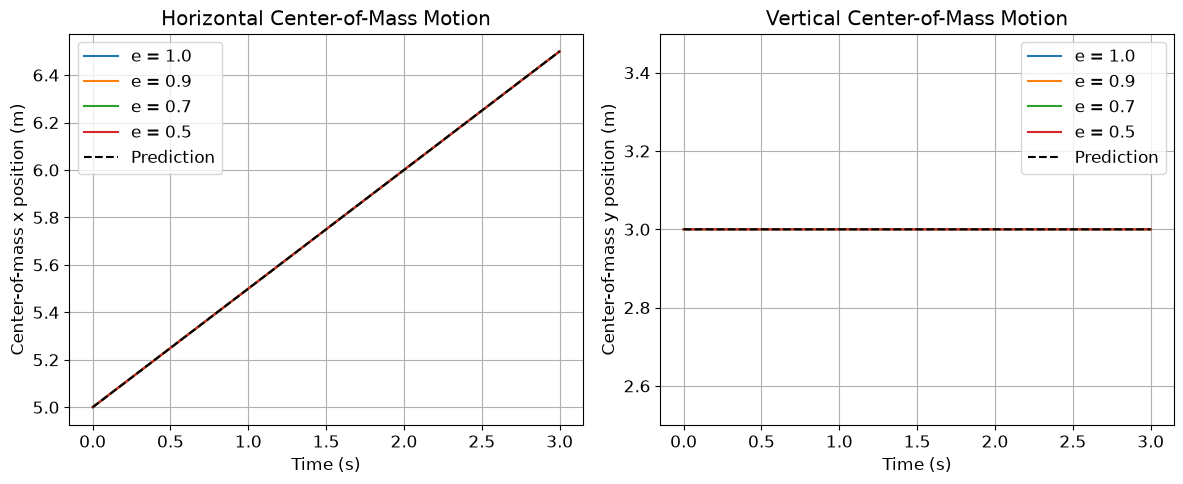

In [13]:
# Calculate the initial center-of-mass position and velocity.
total_mass = sum(body["m"] for body in initial_bodies)

R0 = np.zeros(2)
V_cm = np.zeros(2)

for body in initial_bodies:
    R0 += body["m"] * body["r"]
    V_cm += body["m"] * body["v"]

R0 /= total_mass
V_cm /= total_mass

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

print("Initial center-of-mass position (m):", R0)
print("Predicted center-of-mass velocity (m/s):", V_cm)
print()
print(f"{'e':>5} {'Maximum position error (m)':>30}")

for e in e_values:
    # Remove wall interactions for this check.
    results = simulate_disks(
        initial_bodies=initial_bodies,
        dt=dt,
        n_steps=n_steps,
        Lx=Lx,
        Ly=Ly,
        e=e,
        walls=False,
    )

    time = results["time"]
    simulated_cm = results["center_of_mass"]

    # Calculate the predicted position at every stored time.
    predicted_cm = np.zeros_like(simulated_cm)
    predicted_cm[:, 0] = R0[0] + V_cm[0] * time
    predicted_cm[:, 1] = R0[1] + V_cm[1] * time

    # Find the distance between the simulated and predicted positions.
    position_error = np.linalg.norm(
        simulated_cm - predicted_cm, axis=1
    )

    print(f"{e:>5.1f} {np.max(position_error):>30.3e}")

    axes[0].plot(time, simulated_cm[:, 0], label=f"e = {e:.1f}")
    axes[1].plot(time, simulated_cm[:, 1], label=f"e = {e:.1f}")

# All runs use the same times and theoretical center-of-mass motion.
axes[0].plot(
    time, predicted_cm[:, 0], "k--", label="Prediction"
)
axes[1].plot(
    time, predicted_cm[:, 1], "k--", label="Prediction"
)

axes[0].set(
    xlabel="Time (s)",
    ylabel="Center-of-mass x position (m)",
    title="Horizontal Center-of-Mass Motion",
)
axes[1].set(
    xlabel="Time (s)",
    ylabel="Center-of-mass y position (m)",
    title="Vertical Center-of-Mass Motion",
)
axes[1].set_ylim(R0[1] - 0.5, R0[1] + 0.5)

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()

### Part C interpretation

The restitution comparison showed that smaller values of $e$
produced larger kinetic energy losses. Each run started with
4.375 J. The elastic collision kept this energy, while the cases
with $e=0.9$, $0.7$, and $0.5$ lost approximately 16.29%, 43.71%,
and 64.29%, respectively.

The energy stayed constant between collisions and dropped during
the inelastic collisions. The simulated loss fractions agreed with
the head-on theoretical prediction within numerical precision.

With the walls turned off, the center of mass moved horizontally
at 0.5 m/s and stayed at a height of 3.0 m for every restitution
value. This showed that losing kinetic energy in an internal
collision did not change the system's total momentum or
center-of-mass velocity.

Together, these checks support the momentum and energy behavior
of the collision model. They do not fully test the accuracy of
collision detection. A smaller time step would still be needed
to check whether collision times and trajectories converge.

## Bonus: Speed Distribution of Many Disks

I will simulate 36 identical disks undergoing elastic collisions
inside a box. They will start with the same speed and randomly
chosen directions.

Although total kinetic energy should remain constant, individual
disks can gain or lose kinetic energy during collisions. I will
examine how their speed distribution changes and compare the
later distribution with the two-dimensional Maxwell-Boltzmann
prediction.

The stationary walls should preserve kinetic energy but can change
the total momentum of the disks through external impulses.
Therefore, I will check energy conservation and interpret momentum
changes with the wall interactions in mind.

In [14]:
# Use a fixed seed so the random initial conditions are reproducible.
rng = np.random.default_rng(311)

bonus_Lx = 10.0
bonus_Ly = 10.0
disk_mass = 1.0       # kg
disk_radius = 0.30   # m
initial_speed = 1.0  # m/s

# Place the centers on a grid so the disks do not overlap initially.
x_locations = np.linspace(1.0, 9.0, 6)
y_locations = np.linspace(1.0, 9.0, 6)

bonus_bodies = []

for y in y_locations:
    for x in x_locations:
        angle = rng.uniform(0.0, 2.0 * np.pi)

        velocity = initial_speed * np.array([
            np.cos(angle),
            np.sin(angle),
        ])

        bonus_bodies.append({
            "m": disk_mass,
            "r": np.array([x, y]),
            "v": velocity,
            "radius": disk_radius,
        })

bonus_initial_energy = sum(
    0.5 * body["m"] * np.dot(body["v"], body["v"])
    for body in bonus_bodies
)

print(f"Number of disks: {len(bonus_bodies)}")
print(f"Initial speed of every disk: {initial_speed:.2f} m/s")
print(f"Total initial kinetic energy: {bonus_initial_energy:.2f} J")

Number of disks: 36
Initial speed of every disk: 1.00 m/s
Total initial kinetic energy: 18.00 J


### Running the many-disk simulation

I will simulate the 36 disks for 100 seconds using a time step of
0.01 seconds. All disk-disk and disk-wall collisions will be elastic.

At the initial speed of 1 m/s, a disk travels 0.01 m per step,
which is small compared with its diameter of 0.60 m. Individual
speeds can increase during collisions, so this initial comparison
alone does not guarantee accurate collision detection.

I will check the total kinetic energy throughout the run. It should
remain at 18 J even though collisions redistribute energy among
the disks.

I will also plot both components of total momentum. These can change
when disks hit the walls, since the walls exert external impulses.
A change in the disks' total momentum is therefore not automatically
a sign of an error.

Running for a long time does not by itself establish that the speed
distribution has settled. I will examine the later speed data before
drawing that conclusion.

Simulation duration: 100.0 s
Stored time points: 10001
Initial kinetic energy: 18.000000 J
Final kinetic energy: 18.000000 J
Maximum absolute energy deviation: 3.197e-14 J
Maximum relative energy deviation: 1.776e-15


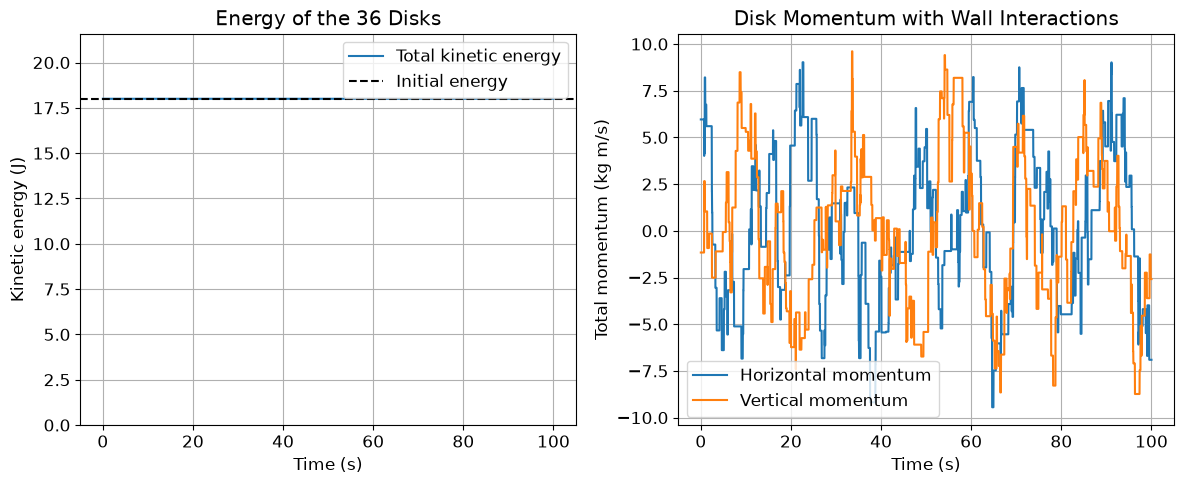

In [15]:
# Run 100 seconds of elastic disk motion.
bonus_dt = 0.01
bonus_n_steps = 10000

bonus_results = simulate_disks(
    initial_bodies=bonus_bodies,
    dt=bonus_dt,
    n_steps=bonus_n_steps,
    Lx=bonus_Lx,
    Ly=bonus_Ly,
    e=1.0,
    walls=True,
)

# Retrieve the stored results.
bonus_time = bonus_results["time"]
bonus_energy = bonus_results["kinetic_energy"]
bonus_momentum = bonus_results["momentum"]

# Measure the maximum energy deviation over the entire run.
max_energy_error = np.max(
    np.abs(bonus_energy - bonus_energy[0])
)
relative_energy_error = max_energy_error / bonus_energy[0]

print(f"Simulation duration: {bonus_time[-1]:.1f} s")
print(f"Stored time points: {len(bonus_time)}")
print(f"Initial kinetic energy: {bonus_energy[0]:.6f} J")
print(f"Final kinetic energy: {bonus_energy[-1]:.6f} J")
print(f"Maximum absolute energy deviation: {max_energy_error:.3e} J")
print(f"Maximum relative energy deviation: {relative_energy_error:.3e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Check energy conservation.
axes[0].plot(bonus_time, bonus_energy, label="Total kinetic energy")
axes[0].axhline(
    bonus_energy[0],
    color="black",
    linestyle="--",
    label="Initial energy",
)
axes[0].set(
    xlabel="Time (s)",
    ylabel="Kinetic energy (J)",
    title="Energy of the 36 Disks",
    ylim=(0, 1.2 * bonus_energy[0]),
)
axes[0].legend()

# Show momentum changes due to wall impulses.
axes[1].plot(
    bonus_time, bonus_momentum[:, 0], label="Horizontal momentum"
)
axes[1].plot(
    bonus_time, bonus_momentum[:, 1], label="Vertical momentum"
)
axes[1].set(
    xlabel="Time (s)",
    ylabel="Total momentum (kg m/s)",
    title="Disk Momentum with Wall Interactions",
)
axes[1].legend()

plt.tight_layout()
plt.show()

### Comparing the speed distribution with theory

I will calculate each disk's speed from its velocity components:

$$
v=\sqrt{v_x^2+v_y^2}.
$$

All disks started at 1 m/s, but elastic collisions can redistribute
their kinetic energy. I will compare the final speed histogram with
a histogram combining samples from the second half of the simulation.

For an equilibrium gas in two dimensions, the Maxwell-Boltzmann
speed distribution can be written as:

$$
f(v)=\frac{2v}{\langle v^2\rangle}
\exp\left(-\frac{v^2}{\langle v^2\rangle}\right),
\qquad v\geq 0.
$$

Here, $\langle v^2\rangle$ is the mean squared speed. Since the disks
have equal masses and total kinetic energy is conserved:

$$
\langle v^2\rangle=\frac{2K}{Nm}.
$$

For this simulation, the predicted mean squared speed is
$1.0\ \mathrm{m^2/s^2}$.

The histogram will show probability density, so its total area is
one. A single snapshot contains only 36 speeds and may look uneven.
Combining later samples will show the distribution more clearly,
although samples from the same simulation are not fully independent.

I will use the theoretical curve as a comparison rather than assume
that the simulation has already reached equilibrium.

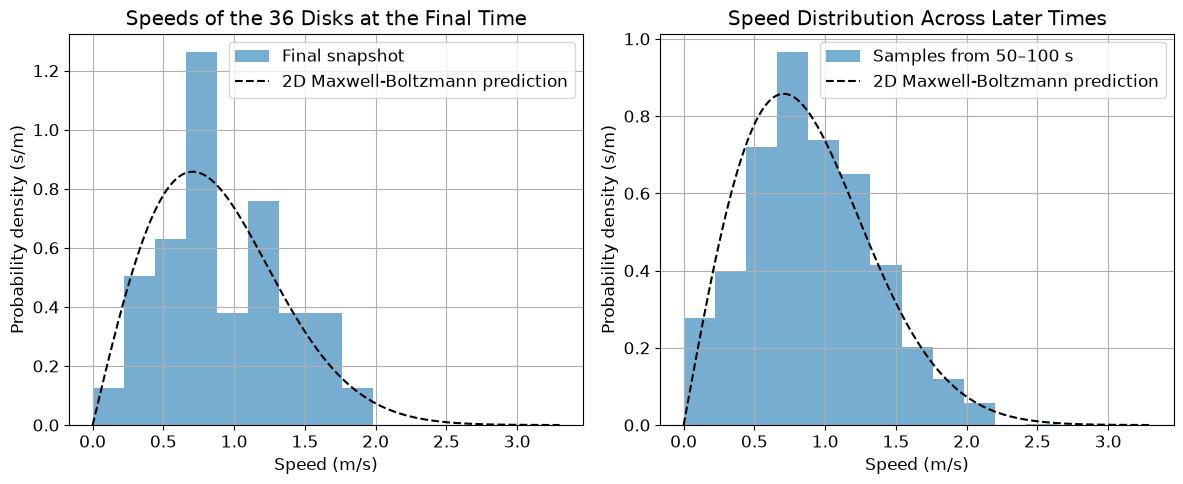

Final snapshot: 36 speeds
Combined later samples: 1836 speeds
Predicted mean squared speed: 1.000000 m²/s²
Sampled mean squared speed: 1.000000 m²/s²


In [16]:
# Calculate speed from the two velocity components at every stored time.
bonus_speeds = np.linalg.norm(
    bonus_results["velocities"], axis=2
)

# Select the final snapshot.
final_speeds = bonus_speeds[-1]

# Sample every 100 steps (1 second) from the second half of the run.
halfway_index = len(bonus_time) // 2
late_speed_samples = bonus_speeds[halfway_index::100].ravel()

# Predict the mean squared speed from the initial total energy.
number_of_disks = len(bonus_bodies)
mean_squared_speed = (
    2 * bonus_energy[0] / (number_of_disks * disk_mass)
)

# Use the same speed range and bins for both histograms.
speed_limit = 1.1 * max(
    np.max(final_speeds),
    np.max(late_speed_samples),
    3 * np.sqrt(mean_squared_speed),
)
bins = np.linspace(0, speed_limit, 16)
speed_curve = np.linspace(0, speed_limit, 400)

theory_density = (
    2 * speed_curve / mean_squared_speed
    * np.exp(-speed_curve**2 / mean_squared_speed)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(
    final_speeds,
    bins=bins,
    density=True,
    alpha=0.6,
    label="Final snapshot",
)
axes[1].hist(
    late_speed_samples,
    bins=bins,
    density=True,
    alpha=0.6,
    label="Samples from 50–100 s",
)

for ax in axes:
    ax.plot(
        speed_curve,
        theory_density,
        "k--",
        label="2D Maxwell-Boltzmann prediction",
    )
    ax.set_xlabel("Speed (m/s)")
    ax.set_ylabel("Probability density (s/m)")
    ax.legend()

axes[0].set_title("Speeds of the 36 Disks at the Final Time")
axes[1].set_title("Speed Distribution Across Later Times")

plt.tight_layout()
plt.show()

print(f"Final snapshot: {len(final_speeds)} speeds")
print(f"Combined later samples: {len(late_speed_samples)} speeds")
print(f"Predicted mean squared speed: {mean_squared_speed:.6f} m²/s²")
print(
    f"Sampled mean squared speed: "
    f"{np.mean(late_speed_samples**2):.6f} m²/s²"
)

I will also compare speed statistics from 50–75 seconds and
75–100 seconds. Similar values would support the idea that the
distribution has become approximately steady, although two time
windows cannot prove equilibrium. The mean squared speed is
already constrained by energy conservation, so I will also
compare the mean speed and the spread of speeds.

In [17]:
# Sample speeds once per second.
sample_times = bonus_time[::100]
sample_speeds = bonus_speeds[::100]

# Select two non-overlapping windows from the second half of the run.
earlier_window = sample_speeds[
    (sample_times >= 50.0) & (sample_times < 75.0)
].ravel()

later_window = sample_speeds[
    (sample_times >= 75.0) & (sample_times < 100.0)
].ravel()

# Calculate the mean and standard deviation predicted by the 2D distribution.
predicted_mean = 0.5 * np.sqrt(np.pi * mean_squared_speed)
predicted_std = np.sqrt(
    (1 - np.pi / 4) * mean_squared_speed
)

print(
    f"{'Sample':<18} {'Mean (m/s)':>14} "
    f"{'Std. dev. (m/s)':>18} {'Mean v² (m²/s²)':>20}"
)

for label, speeds in [
    ("50–75 s", earlier_window),
    ("75–100 s", later_window),
]:
    print(
        f"{label:<18} {np.mean(speeds):>14.6f} "
        f"{np.std(speeds):>18.6f} {np.mean(speeds**2):>20.6f}"
    )

print(
    f"{'Theory':<18} {predicted_mean:>14.6f} "
    f"{predicted_std:>18.6f} {mean_squared_speed:>20.6f}"
)

Sample                 Mean (m/s)    Std. dev. (m/s)      Mean v² (m²/s²)
50–75 s                  0.893360           0.449342             1.000000
75–100 s                 0.899103           0.437738             1.000000
Theory                   0.886227           0.463251             1.000000


### Bonus interpretation

The many-disk simulation conserved total kinetic energy at 18 J.
The maximum deviation was approximately $3.2\times10^{-14}$ J,
which is consistent with floating-point rounding.

Elastic collisions allow individual disks to gain or lose kinetic
energy while preserving the total. Starting every disk at the same
speed therefore does not require their speeds to remain equal.
The walls also preserve kinetic energy, but they can change the
total momentum of the disks because they exert external impulses.

I compared the simulated speed histograms with the two-dimensional
Maxwell-Boltzmann distribution. Combining samples from later times
provides more speed observations than the final snapshot alone,
but those observations are correlated because they come from the
same simulation.

The mean squared speed should remain at 1 m²/s² because of energy
conservation. Agreement with that value alone does not establish
a Maxwell-Boltzmann distribution. The histogram shape, mean speed,
and spread of speeds provide additional comparisons.

I also compared two later time windows to check whether the speed
statistics were still changing. This is a limited check of whether
the distribution has become steady. A longer run and different
random seeds would provide further evidence.

Energy conservation does not guarantee accurate collision timing.
The simulation detects collisions at discrete time steps, and a
smaller-step comparison would be needed to assess that limitation.